# HeatMap

In [16]:
library(dplyr)
library(purrr)
library(pheatmap)
library(tibble)

create_gene_heatmap <- function(file_paths, gene_list, gene_id_col = "GENE_ID", 
                                scale_rows = TRUE, output_file = NA, csv_output_file = NULL, ...) {
  
  cat("Reading files...\n")
  data_list <- lapply(file_paths, function(file) {
    if (grepl("\\.csv$", file, ignore.case = TRUE)) {
      read.csv(file, stringsAsFactors = FALSE)
    } else if (grepl("\\.txt$|\\.tsv$", file, ignore.case = TRUE)) {
      read.delim(file, stringsAsFactors = FALSE)
    } else {
      stop("Unsupported file format. Use .csv, .txt, or .tsv files.")
    }
  })
  
  if (length(data_list) == 1) {
    cat("Single file provided, skipping merge...\n")
    merged_df <- data_list[[1]]
  } else {
    cat("Merging", length(data_list), "files on", gene_id_col, "...\n")
    suffix_counter <- 1
    merged_df <- reduce(data_list, function(x, y) {
      suffix <- paste0("_", suffix_counter)
      suffix_counter <<- suffix_counter + 1
      inner_join(x, y, by = gene_id_col, suffix = c("", suffix), relationship = "many-to-many")
    })
  }
  
  cat("Total genes after merging:", nrow(merged_df), "\n")
  
  cat("Filtering for", length(gene_list), "selected genes...\n")
  filtered_df <- merged_df %>% filter(.data[[gene_id_col]] %in% gene_list)
  
  cat("Genes found in data:", nrow(filtered_df), "\n")
  
  if (nrow(filtered_df) == 0) {
    stop("No matching genes found in the merged data!")
  }
  
  if (!is.null(csv_output_file)) {
    cat("Saving filtered gene data to CSV at:", csv_output_file, "\n")
    write.csv(filtered_df, csv_output_file, row.names = FALSE)
  }
  
  heatmap_matrix <- filtered_df %>% 
    column_to_rownames(var = gene_id_col) %>% 
    as.matrix()
  
  heatmap_matrix <- apply(heatmap_matrix, 2, as.numeric)
  rownames(heatmap_matrix) <- rownames(filtered_df %>% column_to_rownames(var = gene_id_col))
  
  cat("Removing NA/NaN/Inf values...\n")
  heatmap_matrix[!is.finite(heatmap_matrix)] <- NA
  
  cat("Checking for rows with all NA or zero variance...\n")
  valid_rows <- apply(heatmap_matrix, 1, function(x) {
    sum(!is.na(x)) > 1 && var(x, na.rm = TRUE) > 0
  })
  
  heatmap_matrix <- heatmap_matrix[valid_rows, ]
  
  cat("Genes remaining after filtering NA/invalid rows:", nrow(heatmap_matrix), "\n")
  
  if (nrow(heatmap_matrix) == 0) {
    stop("No valid genes with sufficient data for heatmap!")
  }
  
  heatmap_matrix <- na.omit(heatmap_matrix)
  
  cat("Generating heatmap...\n")
  scale_param <- if (scale_rows) "row" else "none"
  
  p <- pheatmap(heatmap_matrix, 
                scale = scale_param,
                clustering_distance_rows = "euclidean",
                clustering_distance_cols = "euclidean",
                clustering_method = "complete",
                main = "Heatmap of Selected Genes",
                filename = output_file,
                ...)
  
  cat("Heatmap created successfully!\n")
  
  return(p)
}


In [17]:
genes_of_interest <- c("GAB1", "SMAD2", "CCND2", "PPP1R12B", "KCNJ13", "PIK3CA", "PIK3R1", "AKT", "PTEN",
                      "mTOR", "VEGF", "EGFR", "MYC", "KIT", "ERBB2", "MET", "FGFR2", "FGFR3", "PDGFRA",
                      "ITGA1", "ITGA2", "ITGA3", "ITGA4", "ITGA5", "ITGA6", "ITGA7", "ITGA8", "ITGA9",
                      "ITGA10", "ITGA11", "ITGAD", "ITGAE", "ITGAL", "ITGAM", "ITGAV", "ITGA2B", "ITGB1",
                      "ITGB2", "ITGB3", "ITGB4", "ITGB5", "ITGB6", "ITGB7", "ITGB8")

create_gene_heatmap(
  c("Normalized/GSE38265.csv", "Normalized/GSE69626.csv", "Normalized/GSE239446.csv"), 
  genes_of_interest,
  output_file = "Plots/PI3K_heatmap.png",
  csv_output_file = "Plots/PI3K_genes_expression.csv",
  fontsize = 5
)

Reading files...
Merging 3 files on GENE_ID ...
Total genes after merging: 18130 
Filtering for 44 selected genes...
Genes found in data: 41 
Saving filtered gene data to CSV at: Plots/PI3K_genes_expression.csv 
Removing NA/NaN/Inf values...
Checking for rows with all NA or zero variance...
Genes remaining after filtering NA/invalid rows: 41 
Generating heatmap...
Heatmap created successfully!


In [18]:
genes_of_interest <- c("TFAM", "VDAC1", "COX1", "COX2", "MT-CO1", "MT-ATP6", "SDHA", "ATP5A", "UQCRC2", "NDUFB8", 
                       "PTPRC", "HK2", "PKM1", "PKM2", "MYC", "HIF1A", "NRF2", "PARP1", "GLDC", "ESRP1", "MT-ND1", 
                       "MT-ND2", "MT-ND3", "MT-ND4", "MT-ND4L", "MT-ND5", "MT-ND6", "NDUFS1", "NDUFS2", "NDUFS3", 
                       "NDUFS4", "NDUFS5", "NDUFS6", "NDUFS7", "NDUFS8", "NDUFV1", "NDUFV2", "MTCYB", "BCS1L", "SDHB", 
                       "SDHC", "SDHD", "SLC25A4", "SLC25A5", "UCP1", "UCP2", "PGC1A", "POLG", "POLG2", "TWNK", "TK2", 
                       "DGUOK", "SUCLA2", "SUCLG1", "RRM2B", "TYMP", "MPV17", "OPA1", "MFN1", "MFN2", "DRP1", "FIS1", 
                       "PINK1", "PARK2", "NIX", "ULK1", "AMBRA1", "SOD2", "CAT", "GPX1", "SIRT1", "SIRT3", "MT-TL1", 
                       "MT-TK", "MT-TI", "MT-TW", "MT-TG", "ITGA1", "ITGA2", "ITGA3", "ITGA4", "ITGA5", "ITGA6", 
                       "ITGA7", "ITGA8", "ITGA9", "ITGA10", "ITGA11", "ITGAD", "ITGAE", "ITGAL", "ITGAM", "ITGAV", 
                       "ITGA2B", "ITGB1", "ITGB2", "ITGB3", "ITGB4", "ITGB5", "ITGB6", "ITGB7", "ITGB8")

create_gene_heatmap(
  c("CrossPlatfromNormFinal.csv"), 
  genes_of_interest,
  output_file = "Plots/Mito_heatmap.png",
  csv_output_file = "Plots/mito_genes_expression.csv",
  fontsize=3,
  labels_col = NA
)

Reading files...
Single file provided, skipping merge...
Total genes after merging: 12810 
Filtering for 102 selected genes...
Genes found in data: 71 
Saving filtered gene data to CSV at: Plots/mito_genes_expression.csv 
Removing NA/NaN/Inf values...
Checking for rows with all NA or zero variance...
Genes remaining after filtering NA/invalid rows: 71 
Generating heatmap...
Heatmap created successfully!


## Gene Regulation Plot

In [10]:
library(tidyverse)

plot_deg_genes <- function(
  genes_of_interest,
  data_dir = "DEG/Results/FilteredLatest",
  output_file = NULL,
  width = 18,
  height = 10,
  dpi = 600
) {
  
  # Define filename to display name mappings (based on your recode list)
  transition_mappings <- list(
    "filtered_categorized_GSE38265_DE_results_significant_HUES9_vs_iPSC" = "GSE38265",
    "filtered_categorized_GSE69626_DEG_OSKM_vs_ESC_significant" = "GSE69626",
    "filtered_categorized_GSE113253_DEG_AT_vs_Undifferentiated_logFC0_significant" = "GSE113253 Adipogenesis",
    "filtered_categorized_GSE113253_DEG_BM_vs_Undifferentiated_logFC0_significant" = "GSE113253 Osteogenesis",
    "filtered_categorized_GSE139273_DEG_iPSC_vs_iSN_logFC0" = "GSE139273",
    "filtered_categorized_GSE164425_DEG_HSCinducediNKT_vs_NK_logFC0" = "GSE164425",
    "filtered_categorized_GSE239446_logfc0_DEG_reprogrammed_vs_NSC_significant" = "GSE239446",
    "filtered_categorized_GSE252276_DEG_AIPLco_vs_control_logFC0" = "GSE252276"
  )
  
  # Find all CSV files in the directory
  csv_files <- list.files(
    path = data_dir,
    pattern = "\\.csv$",
    full.names = TRUE
  )
  
  if (length(csv_files) == 0) {
    stop("No CSV files found in ", data_dir)
  }
  
  # Read all CSV files and map to display names
  all_data <- map_df(csv_files, function(file) {
    # Get filename without extension
    file_base <- tools::file_path_sans_ext(basename(file))
    
    # Check if this file is in our mapping
    if (file_base %in% names(transition_mappings)) {
      read_csv(file, show_col_types = FALSE) %>%
        mutate(
          Transition = transition_mappings[[file_base]]
        )
    } else {
      # Skip files not in our mapping
      NULL
    }
  })
  
  if (nrow(all_data) == 0) {
    stop("No matching files found or no data read. Check transition_mappings.")
  }
  
  # Check if 'gene' column exists
  if (!"gene" %in% colnames(all_data)) {
    stop("Expected 'gene' column not found in CSV files")
  }
  
  # Filter data for genes of interest
  plot_data <- all_data %>%
    filter(gene %in% genes_of_interest)
  
  if (nrow(plot_data) == 0) {
    warning("No matching genes found in the data.")
    return(NULL)
  }
  
  # Set gene order for x-axis
  plot_data$gene <- factor(
    plot_data$gene,
    levels = genes_of_interest
  )
  
  # Define colors matching the original plot
  transition_colors <- c(
    "GSE38265" = "#F39C12",  # orange
    "GSE69626" = "#4A6FE3",  # blue
    "GSE239446" = "#5DADE2",  # lighter blue
    "GSE113253 Adipogenesis" = "black",
    "GSE113253 Osteogenesis" = "#A93226",  # deep red
    "GSE164425" = "#8E44AD",  # purple
    "GSE139273" = "#16A000",  # teal
    "GSE252276" = "#7F8C8D"   # grey
  )
  
  # Filter colors to only those present in data
  transition_colors <- transition_colors[names(transition_colors) %in% unique(plot_data$Transition)]
  
  # Create the plot
  p <- ggplot(plot_data, aes(x = gene, y = log2FoldChange, fill = Transition)) +
    
    # Bars
    geom_col(
      position = position_dodge(width = 0.8),
      width = 0.5
    ) +
    
    # Zero line
    geom_hline(
      yintercept = 0,
      color = "black",
      linewidth = 0.8
    ) +
    
    # Colors
    scale_fill_manual(values = transition_colors) +
    
    # Labels
    labs(
      x = "Gene",
      y = "log2FoldChange"
    ) +
    
    # Theme
    theme_minimal(base_size = 14) +
    theme(
      plot.background = element_rect(fill = "white", color = NA),
      panel.background = element_rect(fill = "white"),
      panel.grid.major = element_line(color = "black"),
      panel.grid.minor = element_blank(),
      text = element_text(color = "black"),
      axis.text = element_text(color = "black"),
      axis.title = element_text(color = "black"),
      axis.text.x = element_text(size = 10),
      plot.title = element_text(face = "bold", size = 12),
      plot.subtitle = element_text(size = 9),
      legend.background = element_rect(fill = "white"),
      legend.key = element_rect(fill = "white"),
      legend.text = element_text(color = "black"),
      legend.title = element_blank(),
      legend.position = "bottom"
    )
  
  # Save plot if output_file is provided
  if (!is.null(output_file)) {
    ggsave(
      filename = output_file,
      plot = p,
      width = width,
      height = height,
      dpi = dpi,
      bg = "white"
    )
    cat("Plot saved to:", output_file, "\n")
  }
  
  return(p)
}

Plot saved to: Plots/DEG_grouped_bar_log2FC_1.png 


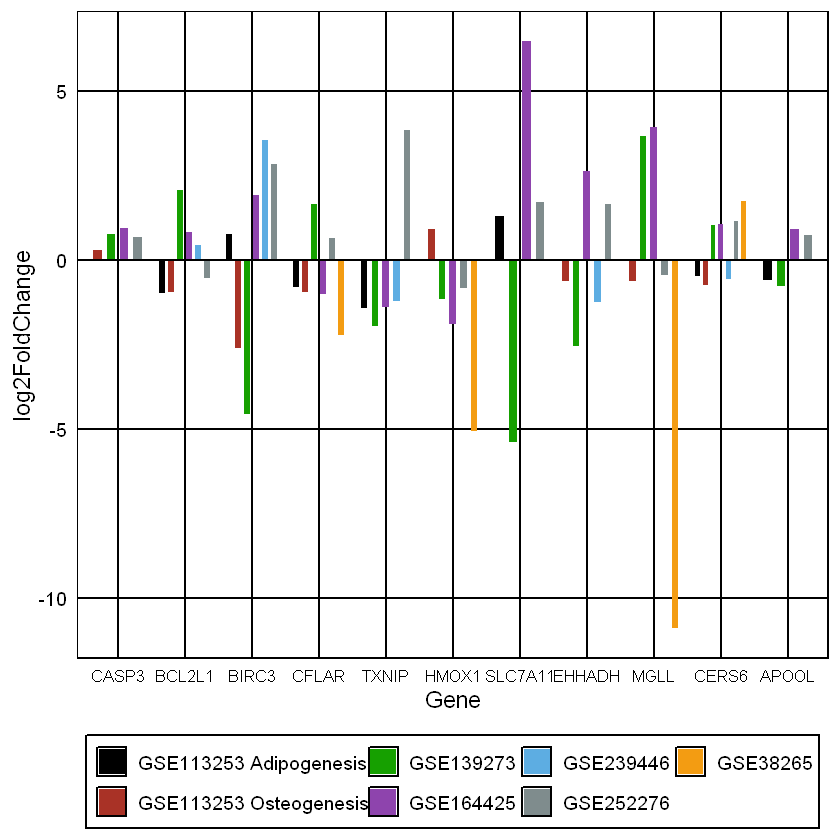

In [15]:
# Example usage:
genes_of_interest <- c(
  "CASP3",
  "BCL2L1",
  "BIRC3",
  "CFLAR",
  "TXNIP",
  "HMOX1",
  "SLC7A11",
  "EHHADH",
  "MGLL",
  "CERS6",
  "APOOL"
)

# Call the function
plot_deg_genes(
  genes_of_interest = genes_of_interest,
  data_dir = "DEG/Results/FilteredLatest",
  output_file = "Plots/DEG_grouped_bar_log2FC_1.png"  # or NULL to not save
)

Plot saved to: Plots/DEG_grouped_bar_log2FC_2.png 


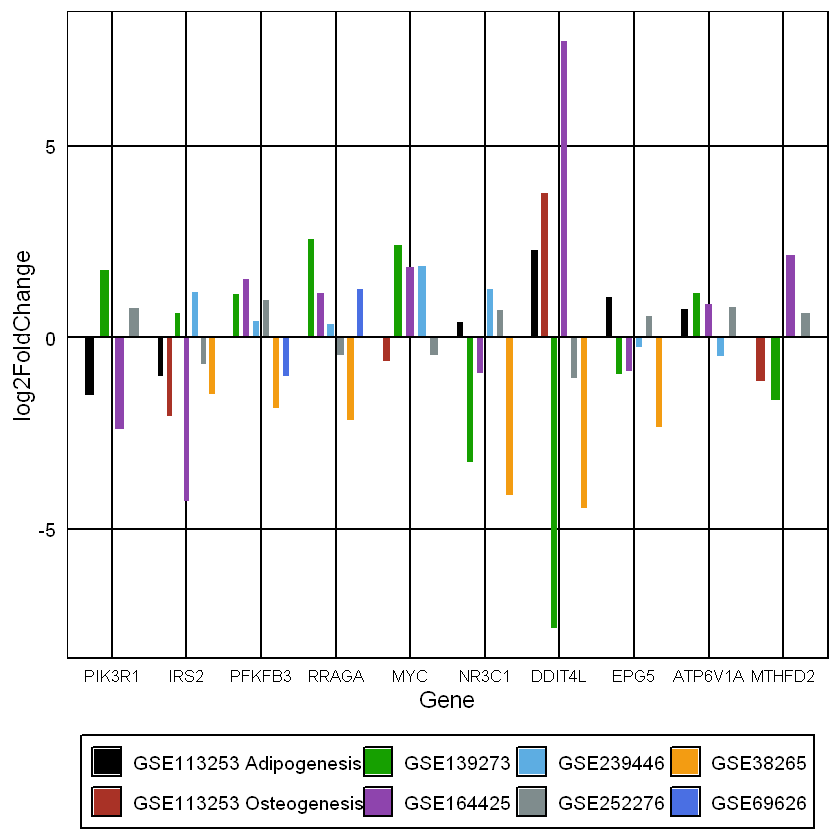

In [13]:
# Example usage:
genes_of_interest <- c(
  "PIK3R1",
  "IRS2",
  "PFKFB3",
  "RRAGA",
  "MYC",
  "NR3C1",
  "DDIT4L",
  "EPG5",
  "ATP6V1A",
  "MTHFD2"
)

# Call the function
plot_deg_genes(
  genes_of_interest = genes_of_interest,
  data_dir = "DEG/Results/FilteredLatest",
  output_file = "Plots/DEG_grouped_bar_log2FC_2.png"  # or NULL to not save
)